# 06 · Threshold 최적화 V2 (운영점 결정)

> PR_AUC가 가장 높은 챔피언(XGB_v2_tuned 0.296)의 확률로 **실사용 threshold**를 정한다.
> threshold 0.5는 임의값이다. 백오더는 놓치는 비용이 크므로, 목적에 맞는 threshold를 따로 찾는다.
> - F1 최적: precision-recall 균형
> - F2 최적: recall을 더 중시(백오더 놓치기 싫을 때)
> - 비용 최적: 놓친 백오더 vs 헛경보의 비용비로 결정
> 핵심 메시지: 같은 모델도 threshold에 따라 운영점이 완전히 달라진다.

## 0. 데이터 + 챔피언 확률 로드

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, f1_score, fbeta_score,
                             recall_score, precision_score, average_precision_score)

from utils import load_processed

PROJECT_ROOT = Path(r"C:\Users\Administrator\Desktop\딥러닝응용\TermProject")
OUT_DIR = PROJECT_ROOT / "processed_v2"
NB_DIR  = PROJECT_ROOT / "notebooks_v2"

_, val_df, _ = load_processed(OUT_DIR)
TARGET = "went_on_backorder"
y_val = val_df[TARGET].values.astype(int)
prob = np.load(NB_DIR / "xgb_v2_val_prob.npy")   # 챔피언 XGB_v2_tuned
print("챔피언 PR_AUC:", round(average_precision_score(y_val, prob), 4), " 양성:", int(y_val.sum()), "/", len(y_val))

챔피언 PR_AUC: 0.2959  양성: 2259 / 337572


## 1. threshold 0.5의 문제
기본 0.5에서의 운영점. 백오더 데이터엔 잘 안 맞는다(보통 너무 적게 잡거나 너무 많이 잡음).

In [2]:
for t in [0.3, 0.5, 0.7]:
    pred = (prob >= t).astype(int)
    print(f"t={t}: Recall {recall_score(y_val, pred):.3f}  Precision {precision_score(y_val, pred, zero_division=0):.3f}  "
          f"F1 {f1_score(y_val, pred, zero_division=0):.3f}  플래그 {pred.mean()*100:.1f}%")

t=0.3: Recall 0.927  Precision 0.057  F1 0.108  플래그 10.8%


t=0.5: Recall 0.870  Precision 0.086  F1 0.157  플래그 6.8%


t=0.7: Recall 0.783  Precision 0.128  F1 0.220  플래그 4.1%


## 2. F1 / F2 최적 threshold
threshold를 훑어 F1(균형)과 F2(recall 중시)가 최대인 지점을 찾는다.

In [3]:
ts = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_val, (prob >= t).astype(int), zero_division=0) for t in ts]
f2s = [fbeta_score(y_val, (prob >= t).astype(int), beta=2, zero_division=0) for t in ts]
t_f1 = ts[int(np.argmax(f1s))]
t_f2 = ts[int(np.argmax(f2s))]

def show(name, t):
    pred = (prob >= t).astype(int)
    print(f"{name}: t={t:.2f}  Recall {recall_score(y_val,pred):.3f}  "
          f"Precision {precision_score(y_val,pred,zero_division=0):.3f}  "
          f"F1 {f1_score(y_val,pred,zero_division=0):.3f}  플래그 {pred.mean()*100:.1f}%")

show("F1 최적", t_f1)
show("F2 최적", t_f2)

F1 최적: t=0.95  Recall 0.359  Precision 0.330  F1 0.344  플래그 0.7%


F2 최적: t=0.87  Recall 0.591  Precision 0.206  F1 0.305  플래그 1.9%


## 3. 비용 민감 threshold
가정: 놓친 백오더(FN)가 헛경보(FP)보다 C_FN/C_FP 배 비싸다.
총비용 = C_FN x 놓친수 + C_FP x 헛경보수. 이 비용이 최소인 threshold를 찾는다.

In [4]:
def total_cost(t, c_fn, c_fp):
    pred = (prob >= t).astype(int)
    fn = int(((pred == 0) & (y_val == 1)).sum())
    fp = int(((pred == 1) & (y_val == 0)).sum())
    return c_fn * fn + c_fp * fp

def best_cost_t(c_fn, c_fp):
    grid = np.linspace(0.001, 0.999, 300)
    costs = [total_cost(t, c_fn, c_fp) for t in grid]
    return grid[int(np.argmin(costs))]

print("비용비  최적t   Recall  Precision  플래그%")
rows = []
for ratio in [2, 5, 10, 20]:
    t = best_cost_t(ratio, 1)
    pred = (prob >= t).astype(int)
    print(f" {ratio:2d}:1   {t:.3f}   {recall_score(y_val,pred):.3f}   "
          f"{precision_score(y_val,pred,zero_division=0):.3f}    {pred.mean()*100:.1f}%")
    rows.append({"비용비": f"{ratio}:1", "최적t": round(t,3),
                 "Recall": round(recall_score(y_val,pred),3),
                 "Precision": round(precision_score(y_val,pred,zero_division=0),3),
                 "플래그%": round(pred.mean()*100,1)})
pd.DataFrame(rows)

비용비  최적t   Recall  Precision  플래그%


  2:1   0.979   0.151   0.535    0.2%


  5:1   0.949   0.366   0.329    0.7%


 10:1   0.899   0.539   0.235    1.5%


 20:1   0.772   0.727   0.153    3.2%


,비용비,최적t,Recall,Precision,플래그%
0,2:1,0.979,0.151,0.535,0.2
1,5:1,0.949,0.366,0.329,0.7
2,10:1,0.899,0.539,0.235,1.5
3,20:1,0.772,0.727,0.153,3.2


## 4. PR 곡선 + 운영점 표시

C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


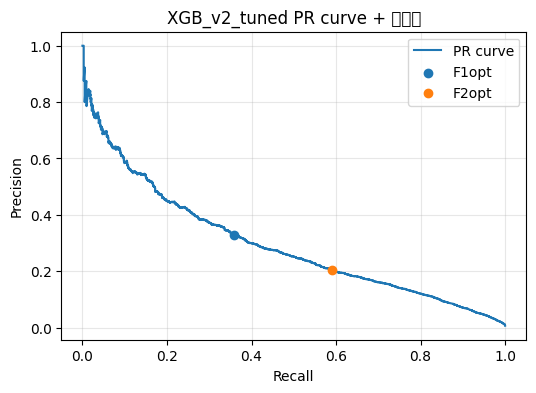

In [5]:
prec, rec, _ = precision_recall_curve(y_val, prob)
plt.figure(figsize=(6,4))
plt.plot(rec, prec, label="PR curve")
for name, t in [("F1opt", t_f1), ("F2opt", t_f2)]:
    pred = (prob >= t).astype(int)
    plt.scatter(recall_score(y_val,pred), precision_score(y_val,pred,zero_division=0), label=name, zorder=5)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("XGB_v2_tuned PR curve + 운영점")
plt.legend(); plt.grid(alpha=0.3); plt.show()

---
### 결론 (운영점 정리)
- threshold 0.5는 챔피언에도 안 맞는다(이 표/그래프가 근거).
- F2 최적·비용비 높을수록 threshold가 낮아져 백오더를 더 많이 잡는다(Recall 상승, Precision 하락).
- 백오더는 놓치는 비용이 크므로, 실무 권장은 비용비 5:1~10:1 근처의 운영점(Recall 확보).
- 핵심: PR_AUC(모델 비교)와 운영점(threshold 후 F1/Recall)은 다른 질문이다. 0.5만 보고 결론내지 않는다.